In [1]:
import os
import numpy as np
import tensorflow as tf
import tensorflow_probability as tfp
from scipy.interpolate import interp1d

# ==========================================
# 1. ENVIRONMENT SETUP
# ==========================================
# Ensure backend is explicitly set for Keras 3 compatibility
os.environ["KERAS_BACKEND"] = "tensorflow"

# Enforce float32 precision for deterministic behavior and GPU acceleration
tf.keras.backend.set_floatx('float32')
tf.random.set_seed(1234)

# ==========================================
# 2. HYPERPARAMETERS & DISCRETIZATION
# ==========================================
# --- Neural Network Architecture ---
NN = 32         # Number of neurons per hidden layer
NL = 5          # Total number of hidden layers

# --- Variational/Training Parameters ---
N_test = 64     # Number of test functions for the weak form evaluation
N_epoch = 100000# Total optimization iterations
batch_size = 256# Number of stochastic quadrature points per batch

# --- Temporal Discretization ---
Time = 0.25     # Final physical time T
t_steps = 128   # Number of temporal increments (N_t)
delta_t = np.float32(Time / t_steps) # Uniform time step size (\Delta t)

# ==========================================
# 3. EMPIRICAL DATA & INTERPOLATION
# ==========================================
# --- Dirichlet Boundary Conditions (g(t)) ---
# Ensure "data_bc.csv" exists in the active directory
loaded_data3 = np.loadtxt("data_bc.csv", delimiter=",", skiprows=1)
bc_data = loaded_data3[:, 1]

# Map empirical data timestamps to the normalized simulation domain [0, Time]
t_data = np.arange(1, len(bc_data) + 1) * Time / len(bc_data)

# Construct a linear interpolator for the empirical boundary curve g(t)
bc_interp_func = interp1d(t_data, bc_data, kind='linear', fill_value="extrapolate")

# Evaluate g(t) exactly at the network's discrete time predictions: t_n = n * \Delta t
t_vals_np = (np.arange(1, t_steps + 1) * delta_t).astype(np.float32)
bc_exact_vals = bc_interp_func(t_vals_np).astype(np.float32)

# --- Non-Linear Thermophysical Parameters ---
# Load temperature-dependent specific heat C(u) and thermal conductivity K(u)
loaded_data = np.loadtxt("properties_dataNonDim.csv", delimiter=",", skiprows=1)
C_curve = tf.cast(loaded_data[:, 1], 'float32')
K_curve = tf.cast(loaded_data[:, 2], 'float32')

# ==========================================
# 4. PHYSICS-INFORMED ARCHITECTURE
# ==========================================
class Cutoff(tf.keras.layers.Layer):
    """
    Hard enforcement of time-dependent Dirichlet boundary conditions.
    Constructs the trial function space mathematically:
        u(x,t) = g(t) + x(1-x) * N_\theta(x,t)
    where g(t) is the empirical boundary data and N_\theta is the neural network output.
    The spatial mask x(1-x) strictly vanishes at the boundaries x=0 and x=1.
    """
    def __init__(self, bc_array, **kwargs):
        super().__init__(**kwargs)
        # Store the interpolated boundary values g(t) as a static constant.
        # Reshaped to (1, t_steps) to allow proper broadcasting over the spatial batch dimension.
        self.bc_values = tf.constant(bc_array.reshape(1, -1), dtype='float32')
        
    def call(self, inputs):
        x, u = inputs
        # Compute the final field variable u(x,t)
        return self.bc_values + (x * (1.0 - x)) * u

def build_model():
    """
    Builds the fully connected neural network N_\theta(x,t).
    Maps a spatial coordinate x \in \Omega to a vector of discrete time predictions \in R^{N_t}.
    """
    X = tf.keras.Input(shape=(1,), dtype='float32')
    
    # Input mapping to the first hidden layer using the Swish activation function
    L = tf.keras.layers.Dense(units=NN, activation='swish')(X)
    
    # Construct the subsequent hidden layers
    for _ in range(NL - 1):
        L = tf.keras.layers.Dense(units=NN, activation='swish')(L)
        
    # Output layer yielding unconstrained predictions for all discrete time steps simultaneously
    L_last = tf.keras.layers.Dense(units=t_steps)(L)
    
    # Apply the spatial mask and boundary condition anchor
    L_out = Cutoff(bc_array=bc_exact_vals)([X, L_last])
    
    return tf.keras.Model(inputs=X, outputs=L_out)

2026-03-01 15:24:36.309310: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-03-01 15:24:36.309329: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-03-01 15:24:36.309333: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
2026-03-01 15:24:36.309347: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-03-01 15:24:36.309354: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [2]:

# ==========================================
# 1. NON-LINEAR VARIATIONAL LOSS
# ==========================================
class StochasticVariationalLoss(tf.keras.layers.Layer):
    """
    Computes the residual of the fully non-linear PDE using a variational formulation.
    Governing equation: $\partial_t (C(u)u) - \nabla \cdot (K(u) \nabla u) = 0$
    Test functions: $v_k \in H^1(\Omega)$, taking into account non-homogeneous boundaries.
    """
    def __init__(self, U_model, batch_size, N_test, delta_t, C_curve, K_curve, **kwargs):
        super().__init__(**kwargs)
        self.U_model = U_model
        self.batch_size = batch_size
        self.dt = tf.cast(delta_t, dtype='float32')
        
        # Mathematical Constants
        self.pi = tf.constant(np.pi, dtype='float32')
        self.sqrt_2 = tf.constant(np.sqrt(2), dtype='float32')
        
        # Test function wave numbers $k = 1, 2, ..., N_{test}$
        self.k = tf.range(1, N_test + 1, dtype='float32')[:, None]
        
        # Empirical property tensors
        self.C_curve = C_curve
        self.K_curve = K_curve

    @tf.function(jit_compile=False) # False avoids M4 platform errors
    def call(self, inputs):
        # --- 1. Stochastic Midpoint Quadrature ---
        # Draw uniform random samples and augment with domain boundaries $x \in \{0, 1\}$
        r = tf.random.uniform(shape=(self.batch_size,), minval=0.0, maxval=1.0)
        sorted_points = tf.sort(tf.concat([[0.0], r, [1.0]], axis=0))
        
        # Calculate integration midpoints $S$ and segment widths $W$ (dx)
        S = (sorted_points[:-1] + sorted_points[1:]) / 2.0
        W = sorted_points[1:] - sorted_points[:-1]
        S_in = S[:, None]

        # --- 2. Neural Network Forward Pass & Automatic Differentiation ---
        with tf.GradientTape() as tape:
            tape.watch(S_in)
            u_pred = self.U_model(S_in) 
        
        # Extract the spatial Jacobian $\nabla u(x,t)$
        u_x = tape.batch_jacobian(u_pred, S_in)[:, :, 0]
        
        # Transpose matrices to shape: (Time, Quadrature_Points) for einsum alignment
        u = tf.transpose(u_pred)
        u_x_t = tf.transpose(u_x)
        
        # --- 3. Orthonormal Basis Functions in $H^1(\Omega)$ ---
        # $v_k(x) = \frac{\sqrt{2}}{\sqrt{1 + (k\pi)^2}} \sin(k\pi x)$
        # $\nabla v_k(x) = \frac{\sqrt{2} k\pi}{\sqrt{1 + (k\pi)^2}} \cos(k\pi x)$
        arg = self.k * self.pi * S[None, :]
        denom = tf.sqrt(1.0 + (self.pi * self.k)**2)
        
        G = (1.0 / denom) * self.sqrt_2 * tf.sin(arg)
        H = (1.0 / denom) * self.pi * self.k * self.sqrt_2 * tf.cos(arg)
        
        # --- 4. Explicit Time Discretization & Initial Condition ---
        # Impose $u(x,0) = 1.0$ strictly into the temporal sequence
        u_prev = tf.concat([tf.ones_like(S)[None, :], u[:-1, :]], axis=0)

        # --- 5. Property Interpolation ---
        # Map current and previous temperatures to empirical $C(u)$ and $K(u)$ properties
        # Grid range covers dimensionless temperatures from -0.9375 to 1.0625
        C_i0 = tfp.math.interp_regular_1d_grid(u_prev, -0.9375, 1.0625, self.C_curve)
        C_i = tfp.math.interp_regular_1d_grid(u_prev, -0.9375, 1.0625, self.C_curve)
        K_i = tfp.math.interp_regular_1d_grid(u, -0.9375, 1.0625, self.K_curve)
        
        # --- 6. Weak Form Integral Assembly (Einsum) ---
        # Indices: 't' (Time), 'b' (Quadrature batch), 'k' (Test function index)
        # $I_{u0} = \int C(u^{n-1}) u^{n-1} v_k dx$
        I_u0 = tf.einsum('tb,tb,b,kb->tk', u_prev, C_i0, W, G)
        
        # $I_u = \int C(u^{n-1}) u^n v_k dx$
        I_u = tf.einsum('tb,tb,b,kb->tk', u, C_i, W, G)
        
        # $I_{grad} = \int K(u^n) \nabla u^n \cdot \nabla v_k dx$
        I_grad = tf.einsum('tb,tb,b,kb->tk', u_x_t, K_i, W, H)
        
        # --- 7. Total Residual Computation ---
        # $\mathcal{L} = \sum_{t} \sum_{k} \left[ \frac{I_u - I_{u0}}{\Delta t} + I_{grad} \right]^2 \Delta t$
        return tf.reduce_sum(tf.square((I_u-I_u0)/ self.dt + I_grad)) * self.dt


# ==========================================
# 2. LINEAR CONTROL VARIATIONAL LOSS ($u_0$)
# ==========================================
class StochasticVariationalLoss0(tf.keras.layers.Layer):
    """
    Computes the residual of the linear heat equation PDE (constant parameters).
    Governing equation: $\partial_t u - \Delta u = 0$
    """
    def __init__(self, U_model, batch_size, N_test, delta_t, **kwargs):
        super().__init__(**kwargs)
        self.U_model = U_model
        self.batch_size = batch_size
        self.dt = tf.cast(delta_t, dtype='float32')
        self.pi = tf.constant(np.pi, dtype='float32')
        self.sqrt_2 = tf.constant(np.sqrt(2), dtype='float32')
        self.k = tf.range(1, N_test + 1, dtype='float32')[:, None]

    @tf.function(jit_compile=False) 
    def call(self, inputs):
        # --- 1. Stochastic Midpoint Quadrature ---
        r = tf.random.uniform(shape=(self.batch_size,), minval=0.0, maxval=1.0)
        sorted_points = tf.sort(tf.concat([[0.0], r, [1.0]], axis=0))
        
        S = (sorted_points[:-1] + sorted_points[1:]) / 2.0
        W = sorted_points[1:] - sorted_points[:-1]
        S_in = S[:, None]

        # --- 2. Neural Network Forward Pass & Gradients ---
        with tf.GradientTape() as tape:
            tape.watch(S_in)
            u_pred = self.U_model(S_in) 
        
        u_x = tape.batch_jacobian(u_pred, S_in)[:, :, 0]
        u = tf.transpose(u_pred)
        u_x_t = tf.transpose(u_x)
        
        # --- 3. Orthonormal Basis Functions in $H^1(\Omega)$ ---
        arg = self.k * self.pi * S[None, :]
        denom = tf.sqrt(1.0 + (self.pi * self.k)**2)
        G = (1.0 / denom) * self.sqrt_2 * tf.sin(arg)
        H = (1.0 / denom) * self.pi * self.k * self.sqrt_2 * tf.cos(arg)
        
        # --- 4. Explicit Time Discretization & Initial Condition ---
        # $u(x,0) = 1.0$
        u_prev = tf.concat([tf.ones_like(S)[None, :], u[:-1, :]], axis=0)
        
        # --- 5. Weak Form Integral Assembly (Einsum) ---
        # Assuming $\mathcal{C} = \mathcal{K} = 1$
        # $I_{u0} = \int u^{n-1} v_k dx$
        I_u0 = tf.einsum('tb,b,kb->tk', u_prev, W, G)
        
        # $I_u = \int u^n v_k dx$
        I_u = tf.einsum('tb,b,kb->tk', u, W, G)
        
        # $I_{grad} = \int \nabla u^n \cdot \nabla v_k dx$
        I_grad = tf.einsum('tb,b,kb->tk', u_x_t, W, H)
        
        # --- 6. Total Residual Computation ---
        # $\mathcal{L} = \sum_{t} \sum_{k} \left[ \frac{I_u - I_{u0}}{\Delta t} + I_{grad} \right]^2 \Delta t$
        return tf.reduce_sum(tf.square((I_u-I_u0)/ self.dt + I_grad)) * self.dt


# ==========================================
# 3. TRAINING CALLBACKS
# ==========================================
class ValidationCallback(tf.keras.callbacks.Callback):
    """
    Custom Keras callback to strictly log the loss dynamically 
    without slowing down the optimization process.
    """
    def __init__(self, interval=100):
        super().__init__()
        self.interval = interval
        self.history = {'loss': [], 'epoch': []}

    def on_epoch_end(self, epoch, logs=None):
        # Extract and log the current loss evaluation at the specified interval
        if (epoch + 1) % self.interval == 0:
            current_loss = logs.get('loss', 0.0)
            self.history['loss'].append(current_loss)
            self.history['epoch'].append(epoch + 1)
            
            # Print status to stdout every 100 epochs
            if (epoch + 1) % 100 == 0:
                print(f"Epoch {epoch+1} | Loss: {current_loss:.2e}")

In [3]:
# ==========================================
# 4. MODEL EXECUTION & OPTIMIZATION LOOP
# ==========================================
# Enforce execution on the primary GPU to accelerate tensor operations
with tf.device('/device:GPU:0'):
    
    # --- Model Instantiation ---
    # U_model approximates the non-linear solution $u_\theta(x,t)$
    U_model = build_model()
    # U_model0 approximates the linear control solution $u_{0,\theta}(x,t)$
    U_model0 = build_model()
    
    # Initialize callbacks to strictly track the variational loss evolution every 500 epochs
    val_cb = ValidationCallback(interval=500)
    val_cb0 = ValidationCallback(interval=500)
    
    # --- Training Graph Assembly ---
    # Dummy input layer required by the Keras functional API structure. 
    # Actual spatial integration coordinates are generated stochastically inside the loss layers.
    training_input = tf.keras.Input(shape=(1,))
    
    # Evaluate the fully non-linear variational residual $\mathcal{L}_{NL}(\theta)$
    loss_val = StochasticVariationalLoss(
        U_model, batch_size, N_test, delta_t, C_curve, K_curve
    )(training_input)
    
    # Evaluate the linear variational residual $\mathcal{L}_{L}(\theta)$
    loss_val0 = StochasticVariationalLoss0(
        U_model0, batch_size, N_test, delta_t
    )(training_input)
    
    # Construct the end-to-end differentiable graphs mapping dummy inputs to the loss scalars
    final_model = tf.keras.Model(inputs=training_input, outputs=loss_val)
    final_model0 = tf.keras.Model(inputs=training_input, outputs=loss_val0)

    # --- Optimization Schedule (Stochastic Gradient Descent with Warm Restarts) ---
    # Implements Cosine Annealing. The learning rate $\eta(t)$ decays following a cosine 
    # curve and abruptly restarts to escape local minima in the highly non-convex PDE loss landscape.
    lr_schedule = tf.keras.optimizers.schedules.CosineDecayRestarts(
        initial_learning_rate=1e-3,
        first_decay_steps=1000,  # $T_i$: Iterations before the first sudden restart
        m_mul=0.9,               # Peak learning rate decay factor: $\eta_{max}^{(i)} = 0.9 \eta_{max}^{(i-1)}$
        alpha=1e-4               # Minimum learning rate lower bound
    )
    
    lr_schedule0 = tf.keras.optimizers.schedules.CosineDecayRestarts(
        initial_learning_rate=1e-3,
        first_decay_steps=1000,  
        m_mul=0.9,               
        alpha=1e-4
    )
    
    # Instantiate the Adam optimizers utilizing the scheduled learning rates
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)
    optimizer0 = tf.keras.optimizers.Adam(learning_rate=lr_schedule0)
    
    # Compile models. Because the custom loss layers compute and output the actual loss value natively,
    # the compilation loss function is strictly an identity mapping: $\mathcal{L}_{compiled}(y_{true}, y_{pred}) = y_{pred}$
    final_model.compile(optimizer=optimizer, loss=lambda y_t, y_p: y_p)
    final_model0.compile(optimizer=optimizer0, loss=lambda y_t, y_p: y_p)

    # --- Training Execution ---
    # Create a minimal zero-tensor to trigger the forward pass calculation sequence.
    # The actual physics collocation points are sampled dynamically inside the model architecture.
    dummy = np.zeros((1, 1), dtype=np.float32)
    
    # Optimize $\theta$ over $N_{epoch}$ iterations for the non-linear problem
    history = final_model.fit(
        dummy, dummy, 
        epochs=N_epoch, 
        verbose=0, 
        callbacks=[val_cb], 
        steps_per_epoch=1
    )
    
    # Optimize $\theta$ over $N_{epoch}$ iterations for the linear control problem
    history0 = final_model0.fit(
        dummy, dummy, 
        epochs=N_epoch, 
        verbose=0, 
        callbacks=[val_cb0], 
        steps_per_epoch=1
    )

2026-03-01 15:24:37.146667: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


Epoch 500 | Loss: 1.80e-03
Epoch 1000 | Loss: 1.06e-03
Epoch 1500 | Loss: 9.33e-04
Epoch 2000 | Loss: 9.17e-04
Epoch 2500 | Loss: 9.05e-04
Epoch 3000 | Loss: 9.02e-04
Epoch 3500 | Loss: 8.59e-04
Epoch 4000 | Loss: 8.19e-04
Epoch 4500 | Loss: 7.90e-04
Epoch 5000 | Loss: 7.56e-04
Epoch 5500 | Loss: 7.14e-04
Epoch 6000 | Loss: 6.72e-04
Epoch 6500 | Loss: 6.46e-04
Epoch 7000 | Loss: 6.42e-04
Epoch 7500 | Loss: 5.66e-04
Epoch 8000 | Loss: 4.33e-04
Epoch 8500 | Loss: 3.04e-04
Epoch 9000 | Loss: 2.92e-04
Epoch 9500 | Loss: 2.72e-04
Epoch 10000 | Loss: 2.56e-04
Epoch 10500 | Loss: 2.43e-04
Epoch 11000 | Loss: 2.32e-04
Epoch 11500 | Loss: 2.24e-04
Epoch 12000 | Loss: 2.18e-04
Epoch 12500 | Loss: 2.13e-04
Epoch 13000 | Loss: 2.10e-04
Epoch 13500 | Loss: 2.07e-04
Epoch 14000 | Loss: 2.06e-04
Epoch 14500 | Loss: 2.05e-04
Epoch 15000 | Loss: 2.05e-04
Epoch 15500 | Loss: 3.58e-04
Epoch 16000 | Loss: 2.25e-04
Epoch 16500 | Loss: 2.05e-04
Epoch 17000 | Loss: 2.05e-04
Epoch 17500 | Loss: 2.00e-04
Epoch

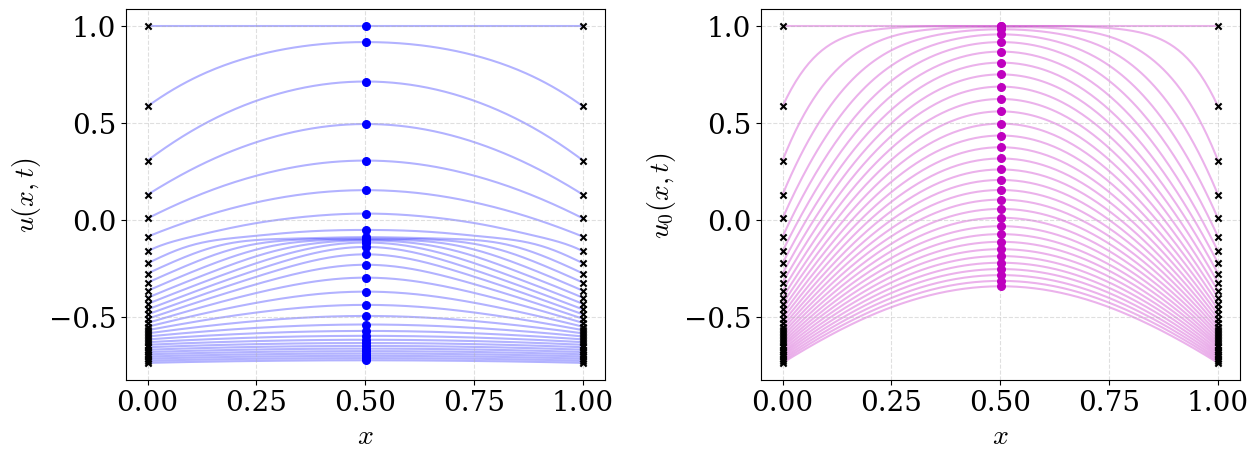

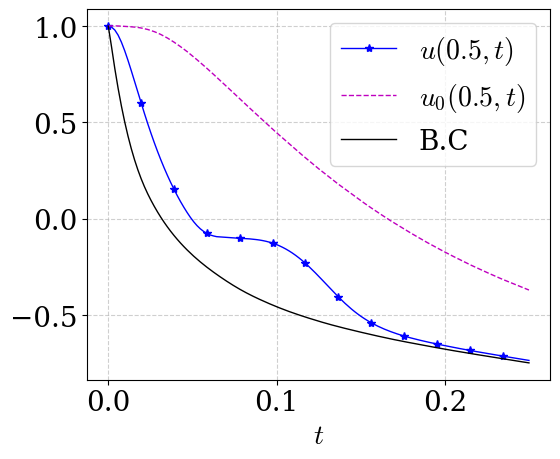

In [22]:
import matplotlib.pyplot as plt
from matplotlib import rcParams

# ==========================================
# 1. PLOT CONFIGURATION
# ==========================================
# Global settings for publication-quality typography
rcParams['font.family'] = 'serif'
rcParams['font.size'] = 20
rcParams['legend.fontsize'] = 20
rcParams['mathtext.fontset'] = 'cm' 
rcParams['axes.labelsize'] = 20

# ==========================================
# 2. GRID EVALUATION & INFERENCE
# ==========================================
# Generate spatial domain discretization $x \in [0, 1]$
xlist = tf.cast(tf.linspace(0.0, 1.0, 200)[:, None], 'float32')

# Evaluate both neural networks to obtain full spatio-temporal predictions.
# Transpose to yield shape: (Time, Space)
uu_raw = tf.transpose(U_model(xlist)).numpy()   # Non-linear solution $u$
uu0_raw = tf.transpose(U_model0(xlist)).numpy() # Linear control solution $u_0$

# Reconstruct the discrete time vector $t_n = n \Delta t$
t_steps = uu_raw.shape[0]
t_list = np.arange(1, t_steps + 1) * delta_t

# Enforce the initial condition $u(x,0) = 1$ strictly into the plotting arrays
t_list_full = np.concatenate(([0.0], t_list))
u_init = np.ones((1, uu_raw.shape[1])) 

uu = np.concatenate((u_init, uu_raw), axis=0)
uu0 = np.concatenate((u_init, uu0_raw), axis=0)

# Extract spatial indices to highlight boundaries and the domain core
left_idx = 0
mid_idx = len(xlist) // 2 
right_idx = -1

x_left = xlist[left_idx, 0]
x_mid = xlist[mid_idx, 0]
x_right = xlist[right_idx, 0]

# ==========================================
# 3. FIGURE 1: SPATIAL PROFILES OVER TIME
# ==========================================
# Compare the diffusion behaviors of the non-linear ($u$) and linear ($u_0$) models side-by-side.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5), sharey=False)

# Define a temporal stride to prevent curve overlapping
step = 4
plot_indices = np.arange(0, t_steps, step)

# --- Subplot 1: Non-Linear Model $u(x,t)$ ---
for t_idx in range(0, t_steps, step):
    ax1.plot(xlist, uu[t_idx, :], color='b', alpha=0.3, zorder=1)

# Overlay structural markers: 'x' for data-driven boundaries, 'o' for the midpoint
ax1.scatter([x_left]*len(plot_indices), uu[plot_indices, left_idx], color='k', marker='x', zorder=2, s=20)
ax1.scatter([x_mid]*len(plot_indices), uu[plot_indices, mid_idx], color='b', marker='o', zorder=2, s=30)
ax1.scatter([x_right]*len(plot_indices), uu[plot_indices, right_idx], color='k', marker='x', zorder=2, s=20)

ax1.set_xlabel("$x$")
ax1.set_ylabel("$u(x,t)$")
ax1.grid(True, linestyle='--', alpha=0.4)

# --- Subplot 2: Linear Control Model $u_0(x,t)$ ---
for t_idx in range(0, t_steps, step):
    ax2.plot(xlist, uu0[t_idx, :], color='m', alpha=0.3, zorder=1)

ax2.scatter([x_left]*len(plot_indices), uu0[plot_indices, left_idx], color='k', marker='x', zorder=2, s=20)
ax2.scatter([x_mid]*len(plot_indices), uu0[plot_indices, mid_idx], color='m', marker='o', zorder=2, s=30)
ax2.scatter([x_right]*len(plot_indices), uu0[plot_indices, right_idx], color='k', marker='x', zorder=2, s=20)

ax2.set_xlabel("$x$")
ax2.set_ylabel("$u_0(x,t)$")
ax2.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig("PaperEXcafe_sol_plots.pdf", bbox_inches='tight')
plt.show()

# ==========================================
# 4. FIGURE 2: MIDPOINT TEMPERATURE EVOLUTION
# ==========================================
# Isolate the transient thermal response at $x=0.5$ for direct model comparison.
fig, ax3 = plt.subplots(1, 1, figsize=(6, 5), sharey=False)

# Plot the core cooling curves
ax3.plot(t_list_full, uu[:, mid_idx], 'b*-', markevery=10, linewidth=1.0, label=r'$u(0.5,t)$')
ax3.plot(t_list_full, uu0[:, mid_idx], 'm--', markevery=10, linewidth=1.0, label=r'$u_0(0.5,t)$')

# Plot the imposed empirical boundary condition for reference
ax3.plot(t_list_full, uu[:, left_idx], 'k-', markevery=10, linewidth=1.0, label=r'B.C.')

ax3.set_xlabel("$t$")
ax3.legend()
ax3.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig("PaperEXcafe_combined_plots.pdf", bbox_inches='tight')
plt.show()


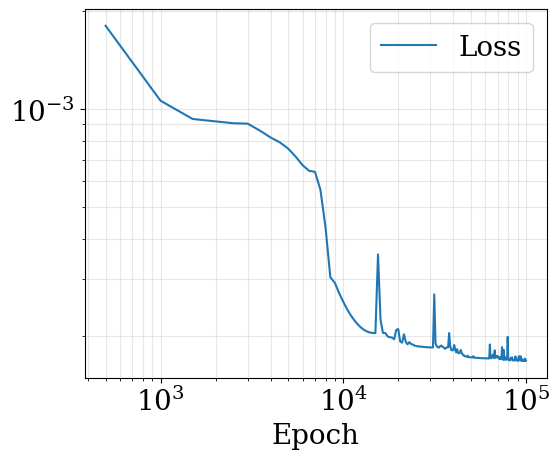

In [8]:
# ==========================================
# 5. LOSS CONVERGENCE VISUALIZATION
# ==========================================
plt.figure(figsize=(6, 5))

# Plot the temporal evolution of the discrete variational residual $\mathcal{L}(\theta)$.
# We apply a log-log scale to clearly evaluate the convergence rate and magnitude drops.
plt.loglog(val_cb.history['epoch'], val_cb.history['loss'], label='Loss')

plt.xlabel("Epoch")
plt.legend()

# Enable major and minor grid lines to precisely track exponential decay
plt.grid(True, which="both", ls="-", alpha=0.3)

plt.tight_layout()

# Export the convergence plot for the manuscript
plt.savefig("PaperEXcafe_lossRaw.pdf")
plt.show()